<a href="https://colab.research.google.com/github/CateaYurkina/CateaYurkina/blob/main/copy_pytorch_rag_assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Иллюстрация общей схемы принципа работы RAG (Retrieval-Augmented Generation)

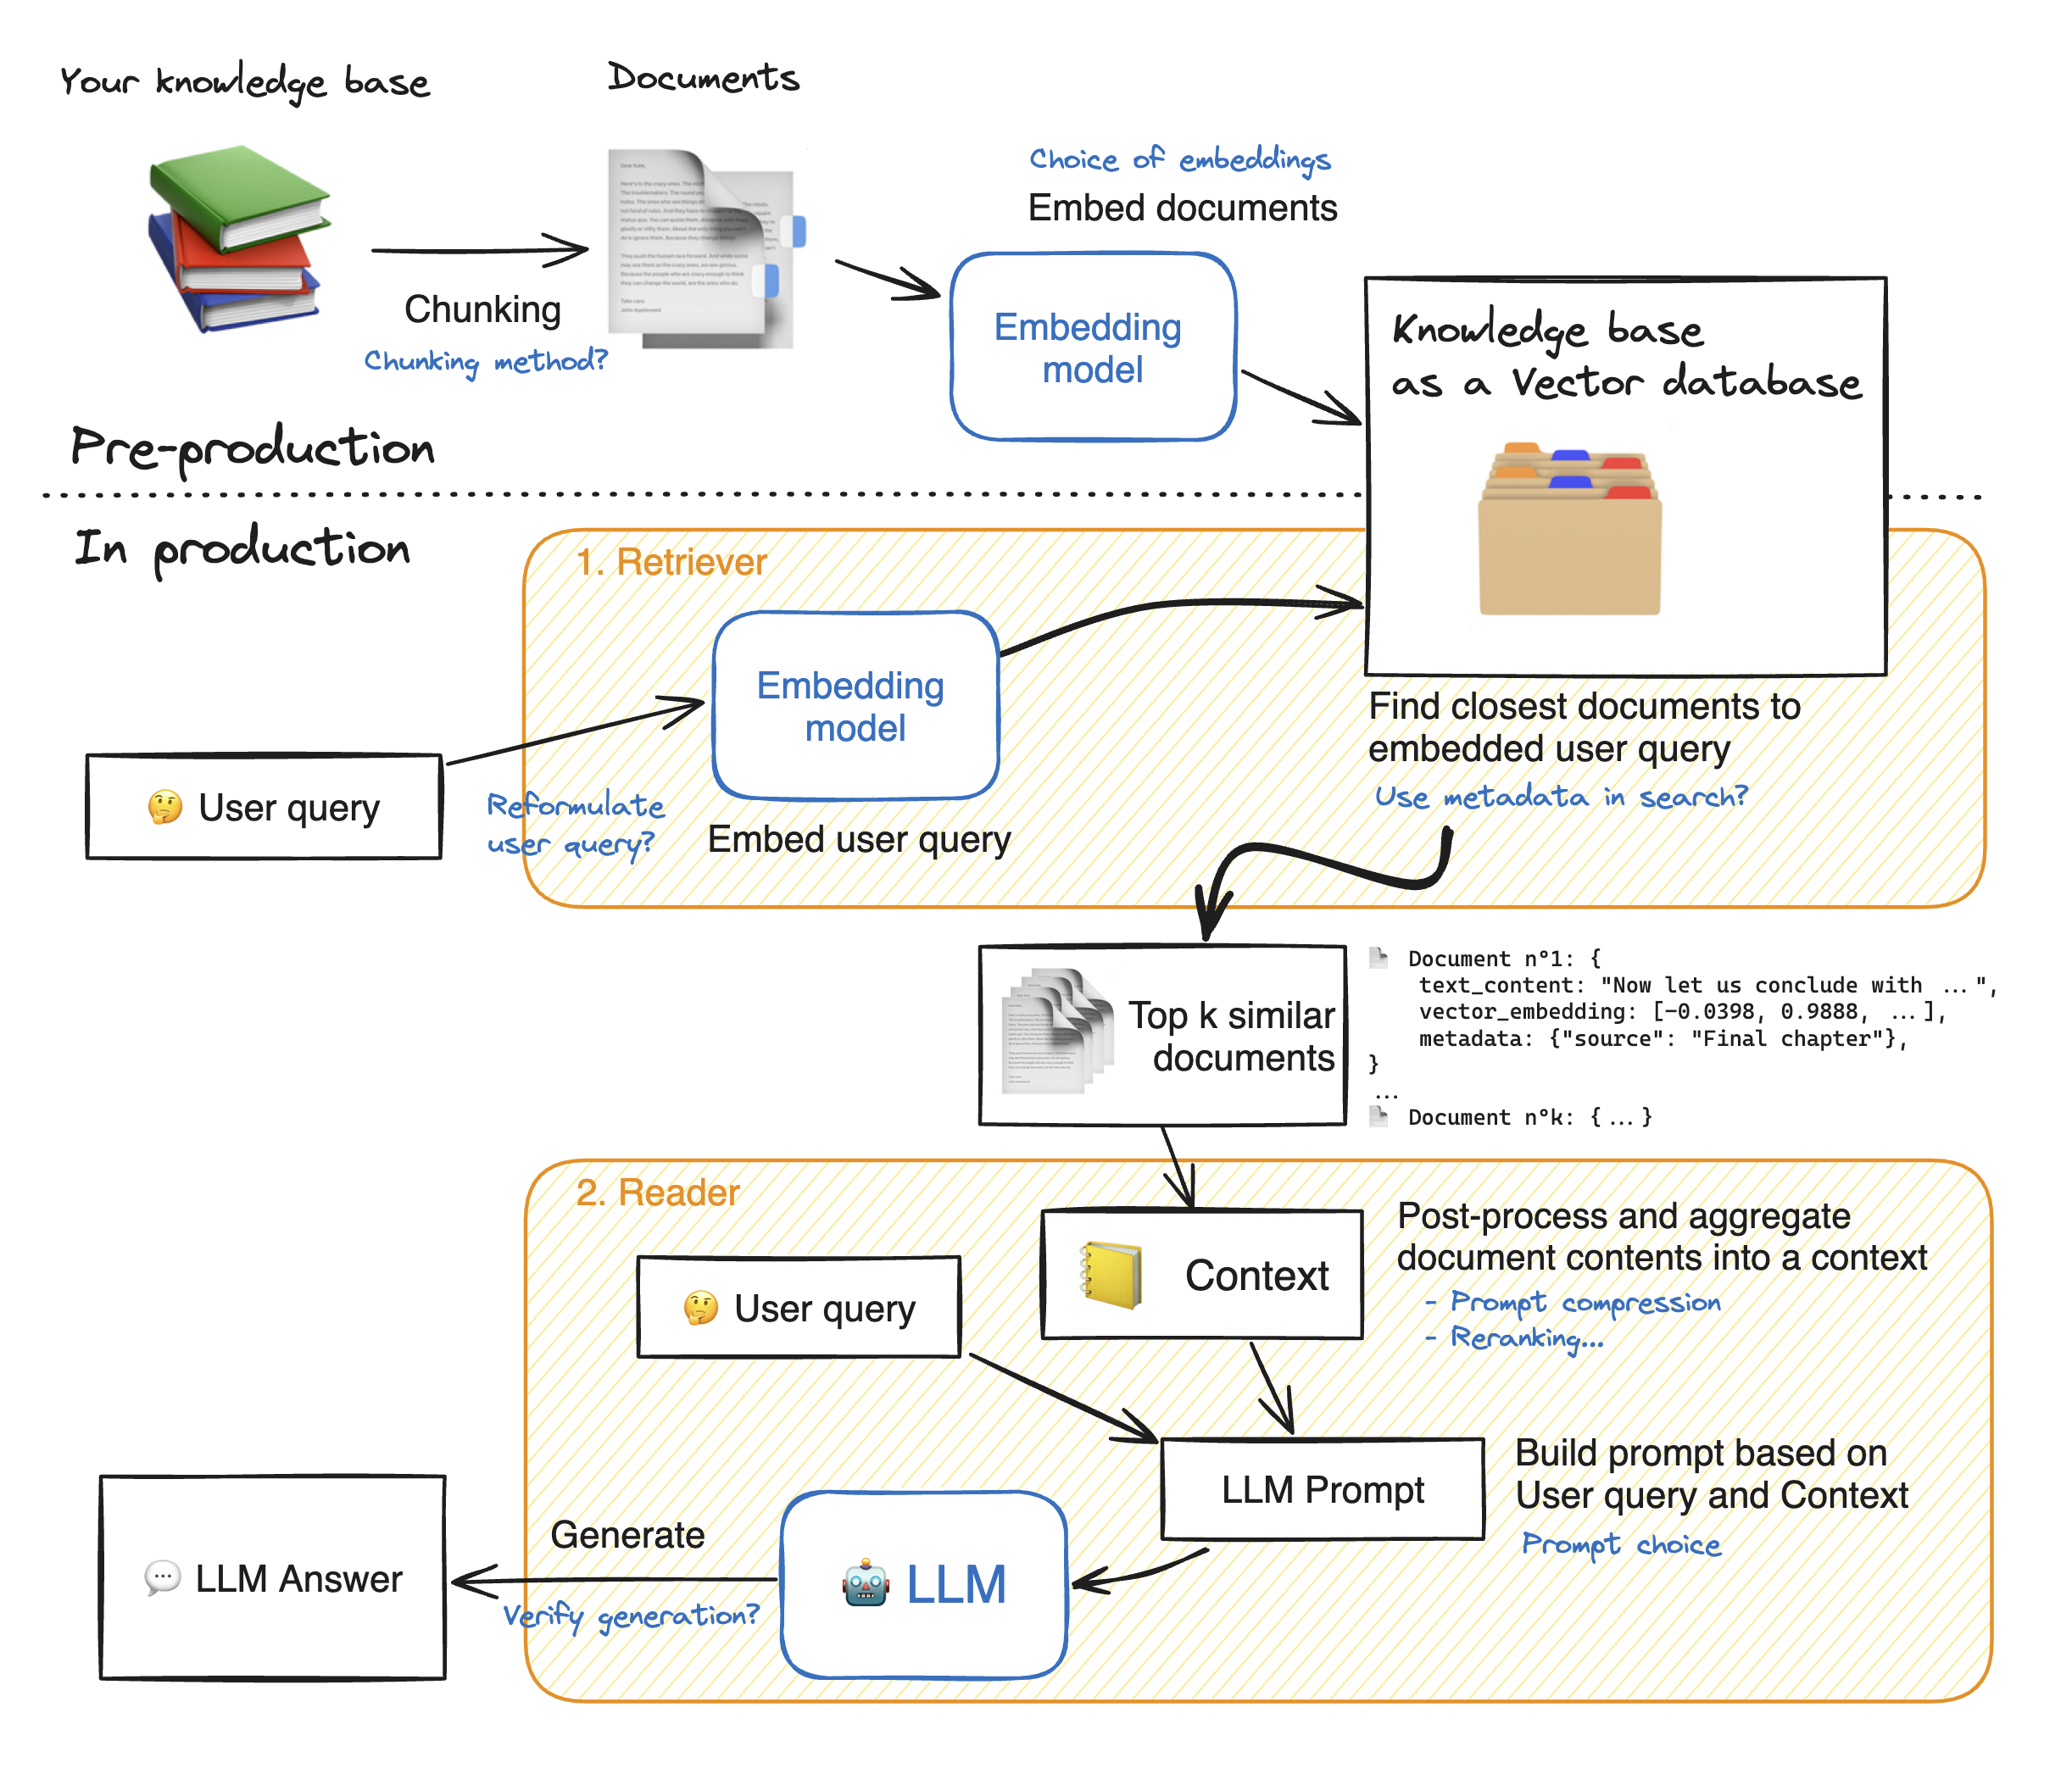

In [ ]:
!pip install -q torch transformers accelerate bitsandbytes langchain sentence-transformers openpyxl pacmap datasets langchain-community ragatouille

In [ ]:
!pip install -q faiss-cpu

# Pre-production

## Loading dataset

In [ ]:
import datasets
# Этот датасет содержит документацию PyTorch в удобном формате
# (источник: https://huggingface.co/datasets)
dataset = datasets.load_dataset("shrinath-suresh/pytorch-tutorial-168", split="train")


In [ ]:
print("✅ Загружено {len(dataset)} документов")
print("\n📄 Пример первого документа:")
print(dataset[0])
print("\nСтруктура датасета:")
print(dataset[0].keys())

✅ Загружено {len(dataset)} документов

📄 Пример первого документа:
{'question': 'What are the two primitives in PyTorch to work with data?', 'context': 'QUICKSTART\nThis section runs through the API for common tasks in machine learning. Refer to the links in each section to dive deeper.\n\nWorking with data\nPyTorch has two primitives to work with data: torch.utils.data.DataLoader and torch.utils.data.Dataset. Dataset stores the samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset.\n\n<code>\nimport torch\nfrom torch import nn\nfrom torch.utils.data import DataLoader\nfrom torchvision import datasets\nfrom torchvision.transforms import ToTensor\n</code>\n\nPyTorch offers domain-specific libraries such as TorchText, TorchVision, and TorchAudio, all of which include datasets. For this tutorial, we will be using a TorchVision dataset.\n\nThe torchvision.datasets module contains Dataset objects for many real-world vision data like CIFAR, COCO (full li

In [ ]:
from tqdm.notebook import tqdm
from langchain_core.documents import Document as LangchainDocument

RAW_KNOWLEDGE_BASE = [ LangchainDocument(page_content=doc["context"]) for doc in tqdm(dataset) ]

  0%|          | 0/168 [00:00<?, ?it/s]

## Разделение текста на смысловые части (чанки):

Один из оптимальных методов разделения на части - рекурсивное деление. Оно разбивает текст на части, используя упорядоченный список разделителей, деля текст сначала по самым важным разделителям.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
# Cписок взят из класса MarkdownTextSplitter в LangChain

separators = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    ". ",
    " ",
    "",
]

In [ ]:
chunk_size = 512
EMBEDDING_MODEL_NAME = "thenlper/gte-small"

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=int(chunk_size/10),
    strip_whitespace=True,
    separators=separators
)

In [ ]:
from transformers import AutoTokenizer

In [ ]:
tokenizer_text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME),
    chunk_size=chunk_size,
    chunk_overlap=int(chunk_size/10),
    strip_whitespace=True,
    separators=separators
)

In [ ]:
docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
  docs_processed += text_splitter.split_documents([doc])

tokenizer_docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
  tokenizer_docs_processed += tokenizer_text_splitter.split_documents([doc])

#Удаление дублей
unique_text = {}
docs_processed_unique = []
for doc in tokenizer_docs_processed:
  if doc.page_content not in unique_text:
    unique_text[doc.page_content]=True
    docs_processed_unique.append(doc)

Вычисление длины контектсного окна:

In [ ]:
from sentence_transformers import SentenceTransformer

print("Максимальная длина контекстного окна:", SentenceTransformer('thenlper/gte-small').max_seq_length)

In [ ]:
import pandas as pd
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("thenlper/gte-small")
lengths = [ len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]

fig = pd.Series(lengths).hist()

In [ ]:
lengths = [ len(tokenizer.encode(doc.page_content)) for doc in tqdm(tokenizer_docs_processed)]

fig = pd.Series(lengths).hist()

# Retriever

## Векторизация чанков

FAISS (Facebook AI Similarity Search) - алгоритм поиска ближайших соседей

**Метрики расстояния:**

Скалярное произведение. Его недостаток в том, что скалярное произведение чувствительно к норме векторов, что может привести к нежелательным эффектам: увеличение нормы вектора делает его более схожим по этому расстоянию с другими векторами.

Косинусное сходство (cosine similarity). Это скалярное произведение, нормированное на норму векторов. Оно оценивает схожесть между двумя векторами как косинус угла между ними. Эта метрика не зависит от нормы векторов.

Евклидово расстояние.

В данной подходе воспользуемся косинусным расстоянием и настроим ее как в модели векторизации, так и в параметре distance_strategy нашего индекса FAISS.

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

In [ ]:
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device":device},
    encode_kwargs={"normalize_embeddings":True}
)

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed_unique, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

## Question

In [ ]:
user_query = "How to create Dropout layer?"
query_vector = embedding_model.embed_query(user_query)

## Визуализация

In [ ]:
import numpy as np
import plotly.express as px
import pacmap

embedding_projector = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0, random_state=1)

embeddings_2d = [
    list(KNOWLEDGE_VECTOR_DATABASE.index.reconstruct_n(idx, 1)[0]) for idx in range(len(docs_processed_unique))
] + [query_vector]

documents_projected = embedding_projector.fit_transform(np.array(embeddings_2d), init="pca")

In [ ]:
docs_processed = docs_processed_unique

In [ ]:
df = pd.DataFrame.from_dict(
    [
        {
            "x": documents_projected[i, 0],
            "y": documents_projected[i, 1],
            "source": i,
            "extract": docs_processed[i].page_content[:100] + "...",
            "symbol": "circle",
            "size_col": 4,
        }
        for i in range(len(docs_processed))
    ]
    + [
        {
            "x": documents_projected[-1, 0],
            "y": documents_projected[-1, 1],
            "source": "User query",
            "extract": user_query,
            "size_col": 100,
            "symbol": "star",
        }
    ]
)

# Визуализируем эмбеддинги
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="source",
    hover_data="extract",
    size="size_col",
    symbol="symbol",
    color_discrete_map={"User query": "black"},
    width=1000,
    height=700,
)
fig.update_traces(
    marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)
fig.update_layout(
    legend_title_text="<b>Источник чанка</b>",
    title="<b>2D-проекция вложений чанка с помощью PaCMAP</b>",
)
fig.show()

## k схожих контестов

In [ ]:
print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=5)
print("\n==================================Top document==================================")
print(retrieved_docs[0].page_content)
print("==================================Metadata==================================")
print(retrieved_docs[0].metadata)

# Reader

## Аугментация

Сайт по рейтингу русских LLM: https://mera.a-ai.ru/ru

In [ ]:
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
READER_MODEL_NAME = "HuggingFaceH4/zephyr-7b-beta"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model = AutoModelForCausalLM.from_pretrained(READER_MODEL_NAME, quantization_config=bnb_config)
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

READER_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=500,
)

In [ ]:
print(READER_LLM("How to create Dropout layer?"))

## Формирование промпта

In [ ]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.""",
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the question you need to answer.

Question: {question}""",
    },
]
RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)
print(RAG_PROMPT_TEMPLATE)

In [ ]:
retrieved_docs_text = [doc.page_content for doc in retrieved_docs]
context = "\nExtracted documents:\n"
context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in enumerate(retrieved_docs_text)])

final_prompt = RAG_PROMPT_TEMPLATE.format(question="How to create Dropout layer?", context=context)

answer = READER_LLM(final_prompt)[0]["generated_text"]
print(answer)

## Реранкинг

Использование кросс-кодера вместо би-кодеров для вычисления более тонких связей между токенами запроса и текнами документов

In [ ]:
from ragatouille import RAGPretrainedModel

RERANKER = RAGPretrainedModel.from_preatrained("colbert-ir/colbertv2.0")

## Generation answer

In [ ]:
relevant_docs = READER_LLM